# A/B-тест нового алгоритма рекомендаций в приложении коротких видео

**Цель:** спланировать A/B-тест нового рекомендательного алгоритма, проверить корректность его проведения и оценить влияние на долю «успешных» первых сессий (4+ просмотренных страниц).

**Этапы:** EDA исторических данных → выбор метрики и расчёт размера выборки и длительности теста → мониторинг корректности сплитования → статистическая проверка результата (z-тест для долей).

## Данные

- исторические сессии пользователей (2025-08-15 — 2025-09-23);
- сессии за первый день теста (2025-10-14);
- сессии за весь период теста (2025-10-14 — 2025-11-02).

Поля: `user_id`, `session_id`, даты сессии и регистрации, номер сессии, группа теста, регион, устройство, число просмотренных страниц.

### Импорт необходимых библиотек и методов

In [1]:
# Импорт инструментов для расчёта мощности теста и эффекта
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Импорт функции для округления вверх
from math import ceil

# Импорт z-теста для сравнения долей
from statsmodels.stats.proportion import proportions_ztest

# Импорт библиотеки для визуализации
import matplotlib.pyplot as plt

### Работа с историческими данными (EDA)

#### Загрузка исторических данных

In [2]:
import io
import ssl
import urllib.request

import pandas as pd

# Базовый адрес для скачивания датасетов, если файлов нет локально
BASE_URL = 'https://code.s3.yandex.net/datasets/'


def load_dataset(filename):
    """Читает датасет: файл рядом с тетрадкой -> папка /datasets/ -> скачивание по ссылке."""
    for path in (filename, '/datasets/' + filename):
        try:
            return pd.read_csv(path)
        except FileNotFoundError:
            continue
    url = BASE_URL + filename
    try:
        return pd.read_csv(url)
    except urllib.error.URLError:
        # Используем certifi, если отсутствуют сертификаты
        import certifi
        context = ssl.create_default_context(cafile=certifi.where())
        with urllib.request.urlopen(url, context=context) as response:
            return pd.read_csv(io.BytesIO(response.read()))


# Загружаем исторические данные о сессиях пользователей
sessions_history = load_dataset('sessions_project_history.csv')

sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### Знакомство с данными

In [3]:
# Число уникальных сессий для каждого пользователя
sessions_per_user = (
    sessions_history
    .groupby('user_id')['session_id']
    .nunique()
    .sort_values(ascending=False)
)

top_user = sessions_per_user.index[0]
print(f'Максимальное число сессий у одного пользователя: {sessions_per_user.iloc[0]}')
print(f'Пользователь с наибольшим числом сессий: {top_user}')

# Все данные по этому пользователю
sessions_history[sessions_history['user_id'] == top_user].sort_values('session_number')

Максимальное число сессий у одного пользователя: 10
Пользователь с наибольшим числом сессий: 10E0DEFC1ABDBBE0


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


**Наблюдения по данным одного пользователя (максимум — 10 сессий):**

- `session_number` увеличивается на 1 с каждой новой сессией, нумерация начинается с 1.
- `install_date` фиксирована и совпадает с датой первой сессии (`session_number` = 1).
- В течение одного дня у пользователя не больше одной сессии (`session_date` не повторяется); сессии идут по дням, возможны пропуски дней.
- `region` и `device` у пользователя не меняются от сессии к сессии.
- `page_counter` меняется от сессии к сессии независимо — это число просмотренных страниц в конкретной сессии.
- `registration_flag` отражает статус регистрации на момент сессии: у данного пользователя в первой сессии — 0, после регистрации он меняется на 1 и далее сохраняется во всех последующих сессиях.

#### Анализ числа регистраций

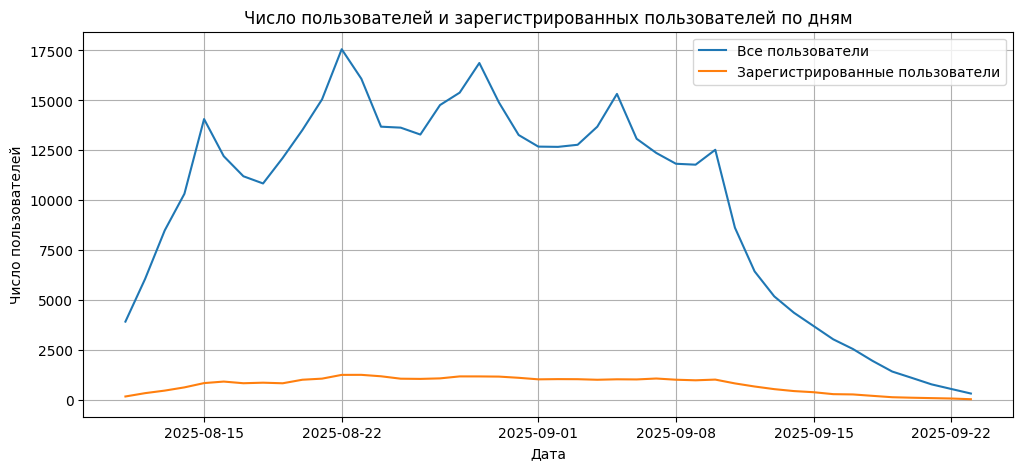

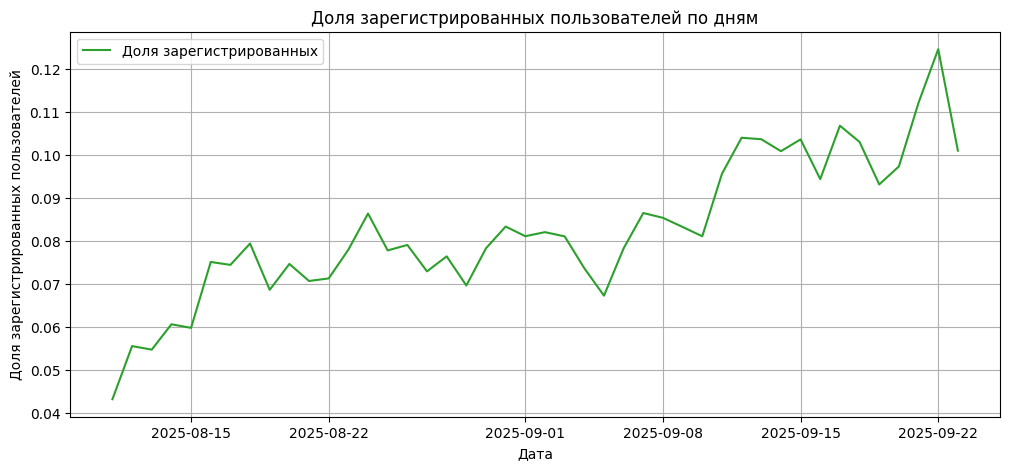

In [4]:
# Агрегируем данные по дням: все уникальные пользователи и зарегистрированные
daily_stats = (
    sessions_history
    .groupby('session_date')
    .agg(
        total_users=('user_id', 'nunique'),
        registered_users=('registration_flag', 'sum')
    )
    .reset_index()
)
daily_stats['registered_share'] = daily_stats['registered_users'] / daily_stats['total_users']
daily_stats['session_date'] = pd.to_datetime(daily_stats['session_date'])

# График числа всех и зарегистрированных пользователей по дням
plt.figure(figsize=(12, 5))
plt.plot(daily_stats['session_date'], daily_stats['total_users'],
         label='Все пользователи')
plt.plot(daily_stats['session_date'], daily_stats['registered_users'],
         label='Зарегистрированные пользователи')
plt.title('Число пользователей и зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Число пользователей')
plt.grid(True)
plt.legend()
plt.show()

# График доли зарегистрированных пользователей по дням
plt.figure(figsize=(12, 5))
plt.plot(daily_stats['session_date'], daily_stats['registered_share'],
         color='tab:green', label='Доля зарегистрированных')
plt.title('Доля зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля зарегистрированных пользователей')
plt.grid(True)
plt.legend()
plt.show()

**Выводы по анализу регистраций:**

- Дневная аудитория росла с ~3,9 тыс. пользователей (11 августа) до пиковых ~17,6 тыс. (22 августа), затем колебалась в диапазоне 12–15 тыс. в день.
- После 10 сентября аудитория резко затухает почти до нуля к 23 сентября. Причина — в устройстве датасета: приток новых пользователей (первых сессий) в данных прекращается после 10 сентября, и далее наблюдается только доживание существующей когорты.
- Число зарегистрированных пользователей в день невелико и повторяет общую динамику аудитории.
- Доля зарегистрированных пользователей колеблется в диапазоне ~4–12% и постепенно растёт к концу периода: по мере затухания когорты в приложении остаются более вовлечённые пользователи, среди которых доля зарегистрированных выше.

#### Анализ числа просмотренных страниц

page_counter
1     8978
2    32494
3    50939
4    32739
5     8075
6      777
7       37
Name: count, dtype: int64


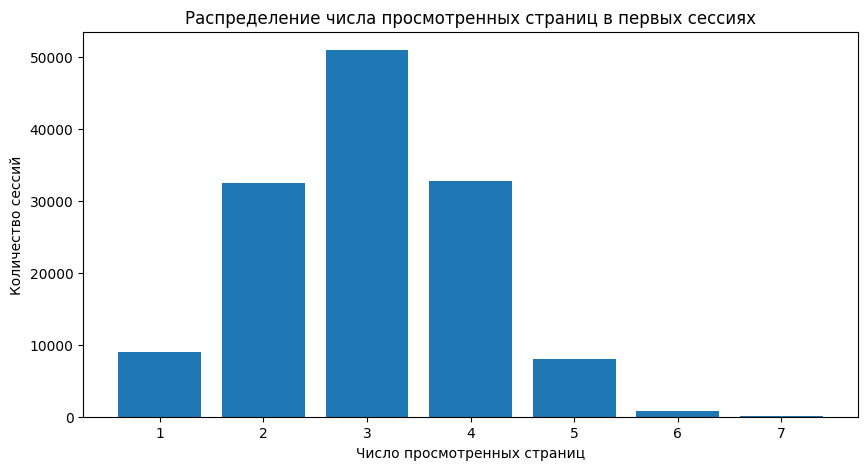

In [5]:
# Первые сессии пользователей
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# Количество первых сессий для каждого значения числа просмотренных страниц
pages_dist = first_sessions['page_counter'].value_counts().sort_index()
print(pages_dist)

plt.figure(figsize=(10, 5))
plt.bar(pages_dist.index, pages_dist.values)
plt.title('Распределение числа просмотренных страниц в первых сессиях')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.show()

**Выводы по анализу числа просмотренных страниц:**

- Распределение числа просмотренных страниц в первых сессиях унимодальное, с модой в 3 страницы (~51 тыс. сессий, около 38% всех первых сессий).
- Большинство первых сессий укладываются в 2–4 страницы; сессии с 6–7 страницами единичны (менее 1%).
- Сессий с 4 и более страницами (порог «успешной» сессии) — около 41,6 тыс. из ~134 тыс., то есть ~31% первых сессий. Это согласуется с базовым уровнем доли p = 0.3, который используется далее при расчёте размера выборки.

#### Доля пользователей, просмотревших более четырёх страниц

Средняя доля успешных первых сессий за весь период: 0.3106


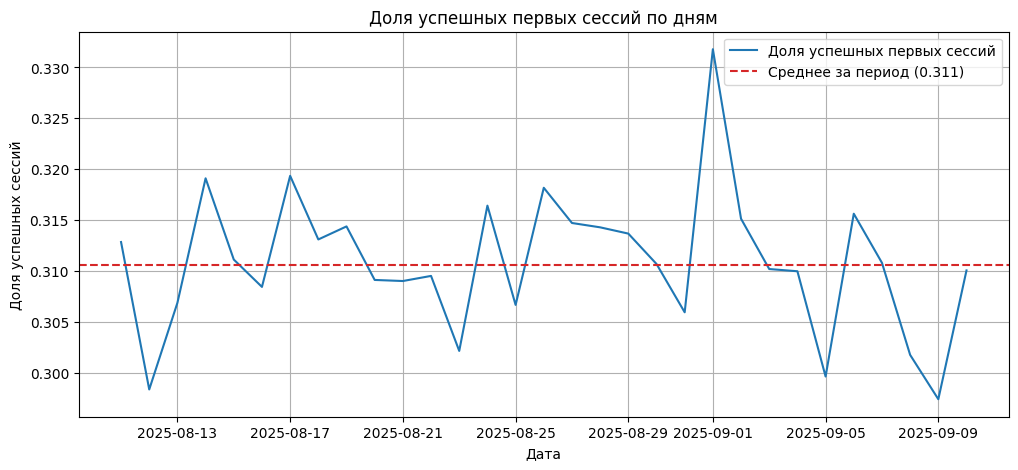

In [6]:
# Столбец good_session: 1, если за сессию просмотрено 4 и более страниц
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

# Доля успешных сессий среди первых сессий пользователей по дням
first_sessions = sessions_history[sessions_history['session_number'] == 1]
good_share_daily = first_sessions.groupby('session_date')['good_session'].mean()
good_share_daily.index = pd.to_datetime(good_share_daily.index)

mean_share = first_sessions['good_session'].mean()
print(f'Средняя доля успешных первых сессий за весь период: {mean_share:.4f}')

plt.figure(figsize=(12, 5))
plt.plot(good_share_daily.index, good_share_daily.values,
         label='Доля успешных первых сессий')
plt.axhline(mean_share, color='tab:red', linestyle='--',
            label=f'Среднее за период ({mean_share:.3f})')
plt.title('Доля успешных первых сессий по дням')
plt.xlabel('Дата')
plt.ylabel('Доля успешных сессий')
plt.grid(True)
plt.legend()
plt.show()

**Выводы по доле успешных первых сессий:**

- Средняя доля успешных первых сессий (4 и более просмотренных страниц) за период — около 31%.
- Показатель стабилен во времени: дневные значения колеблются вокруг среднего без выраженного тренда и сезонности.
- Стабильность метрики позволяет использовать её как целевую метрику A/B-теста, а значение p = 0.3 — как базовый уровень доли при расчёте размера выборки.

### Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### Расчёт размера выборки

In [7]:
# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = p * 0.03  # Минимальный детектируемый эффект: 3% от базового уровня p (0.3 * 0.03 = 0.009)
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1
)

print(f'Необходимый размер выборки: {ceil(sample_size)} пользователей в каждой группе')

Необходимый размер выборки: 41041 пользователей в каждой группе


#### Расчёт длительности A/B-теста

In [8]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = round(sessions_history.groupby('session_date')['user_id'].nunique().mean())

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(2 * sample_size / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день составит 9 дней


**Комментарий к расчёту длительности:**

- При среднем трафике ~9,9 тыс. пользователей в день необходимые 2 × 41 041 = 82 082 участника набираются за 9 дней.
- При этом в эксперименте фактически участвуют только новые пользователи (анализируются первые сессии). Средний дневной приток новых пользователей по историческим данным — около 4,3 тыс. в день, что даёт более консервативную оценку ~19 дней.
- Фактически тест проводился 20 дней (с 2025-10-14 по 2025-11-02), что согласуется с этой оценкой и позволяет сгладить недельную сезонность.

### Мониторинг А/В-теста

#### Проверка распределения пользователей

Дни наблюдения: <StringArray>
['2025-10-14']
Length: 1, dtype: str
test_group
A    1477
B    1466
Name: user_id, dtype: int64
Процентная разница в количестве пользователей групп A и B: 0.74%


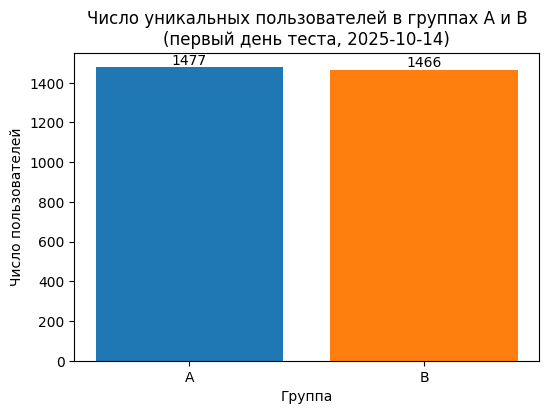

In [9]:
# Загружаем данные за первый день A/B-теста
sessions_test_part = load_dataset('sessions_project_test_part.csv')

print('Дни наблюдения:', sessions_test_part['session_date'].unique())

# Количество уникальных пользователей в каждой группе
users_per_group = sessions_test_part.groupby('test_group')['user_id'].nunique()
print(users_per_group)

# Процентная разница в количестве пользователей: P = 100 * |A - B| / A
a_users = users_per_group['A']
b_users = users_per_group['B']
pct_diff = 100 * abs(a_users - b_users) / a_users
print(f'Процентная разница в количестве пользователей групп A и B: {pct_diff:.2f}%')

plt.figure(figsize=(6, 4))
plt.bar(users_per_group.index, users_per_group.values, color=['tab:blue', 'tab:orange'])
for i, v in enumerate(users_per_group.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.title('Число уникальных пользователей в группах A и B\n(первый день теста, 2025-10-14)')
plt.xlabel('Группа')
plt.ylabel('Число пользователей')
plt.show()

#### Проверка пересечений пользователей

In [10]:
# Множества пользователей каждой группы
users_a = set(sessions_test_part.loc[sessions_test_part['test_group'] == 'A', 'user_id'])
users_b = set(sessions_test_part.loc[sessions_test_part['test_group'] == 'B', 'user_id'])

overlap = users_a & users_b
print(f'Пользователей одновременно в группах A и B: {len(overlap)}')

Пользователей одновременно в группах A и B: 0


#### Равномерность разделения пользователей по устройствам

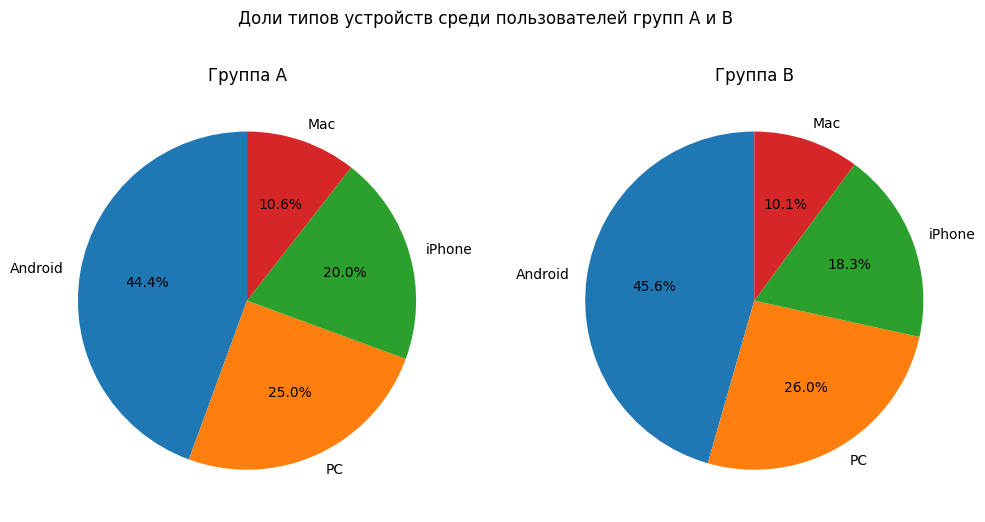

In [11]:
# Оставляем по одной строке на пользователя, чтобы считать доли по пользователям
unique_users = sessions_test_part.drop_duplicates(subset='user_id')

device_share_a = (
    unique_users.loc[unique_users['test_group'] == 'A', 'device']
    .value_counts(normalize=True)
)
device_share_b = (
    unique_users.loc[unique_users['test_group'] == 'B', 'device']
    .value_counts(normalize=True)
    .reindex(device_share_a.index)  # одинаковый порядок категорий
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, shares, group in zip(axes, [device_share_a, device_share_b], ['A', 'B']):
    ax.pie(shares, labels=shares.index, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'Группа {group}')
plt.suptitle('Доли типов устройств среди пользователей групп A и B')
plt.show()

#### Равномерность распределения пользователей по регионам

test_group      A      B
region                  
CIS         0.436  0.440
EU          0.152  0.148
MENA        0.412  0.412


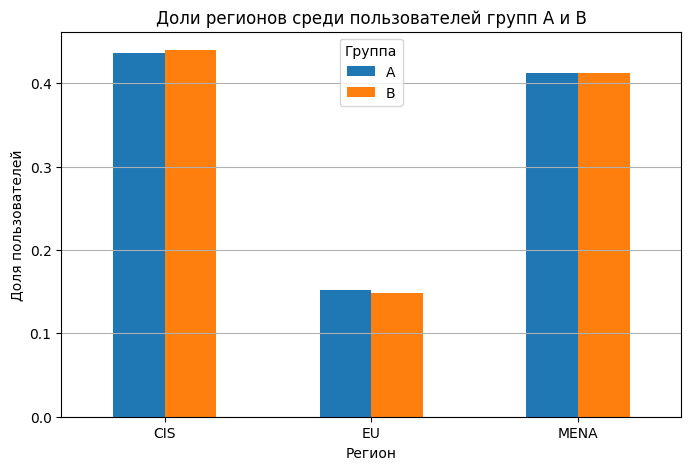

In [12]:
# Доли регионов в каждой группе (по уникальным пользователям)
region_share = (
    unique_users
    .groupby('test_group')['region']
    .value_counts(normalize=True)
    .unstack()
    .T
)
print(region_share.round(3))

region_share.plot(kind='bar', figsize=(8, 5), color=['tab:blue', 'tab:orange'])
plt.title('Доли регионов среди пользователей групп A и B')
plt.xlabel('Регион')
plt.ylabel('Доля пользователей')
plt.legend(title='Группа')
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.show()

#### Вывод после проверки A/B-теста

**Вывод после проверки корректности A/B-теста:**

1. **Количество пользователей в группах.** За первый день теста в группе A — 1477 уникальных пользователей, в группе B — 1466. Процентная разница составляет 0.74%, что меньше порога в 1% — группы можно считать равными по размеру.
2. **Независимость выборок.** Пользователей, попавших одновременно в группы A и B, не обнаружено (0 пересечений) — выборки независимы.
3. **Категориальные переменные.** Распределения пользователей по типам устройств практически совпадают (различия долей не превышают ~2 п.п.), распределения по регионам также близки (различия в пределах ~0.5 п.п.).

**Заключение:** нарушений не выявлено — сплитование работает корректно, группы сбалансированы по размеру, независимы и однородны по устройствам и регионам. A/B-тест проходит корректно, можно продолжать эксперимент и анализировать его результаты.

### Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### Получение результатов теста и подсчёт основной метрики

In [13]:
# Загружаем данные за весь период A/B-теста
sessions_test = load_dataset('sessions_project_test.csv')

# Столбец good_session: 1, если за сессию просмотрено 4 и более страниц
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

print('Период теста:', sessions_test['session_date'].min(), '—', sessions_test['session_date'].max())
sessions_test.head()

Период теста: 2025-10-14 — 2025-11-02


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик

**Целевая метрика** — доля успешных первых сессий (доля первых сессий, в которых просмотрено 4 и более страниц). Новый алгоритм рекомендаций, по мнению команды DS, должен показывать **более** интересный контент, а значит — увеличивать вовлечённость и долю успешных первых сессий. Поскольку в условии задано направление ожидаемого эффекта (улучшение), гипотеза формулируется как односторонняя.

**Гипотезы:**

- **H₀ (нулевая):** доля успешных первых сессий в группе B (новый алгоритм) не выше, чем в группе A (старый алгоритм): p_B ≤ p_A.
- **H₁ (альтернативная):** доля успешных первых сессий в группе B выше, чем в группе A: p_B > p_A.

Уровень значимости: α = 0.05.

**Прокси-метрики** (быстро реагируют и коррелируют с целевой): среднее число просмотренных страниц за сессию, средняя длительность сессии, доля «глубоких» просмотров видео (просмотр более 80%), retention 1-го дня.

**Барьерные (контрольные) метрики** (не должны ухудшиться из-за рисков монетизации): доход от рекламы на пользователя (ARPU рекламной модели), конверсия в платную подписку, отток подписчиков, частота жалоб/скрытий рекламы.

#### Сравнение доли успешных сессий

In [14]:
# Первые сессии пользователей за период теста
first_sessions_test = sessions_test[sessions_test['session_number'] == 1]

good_share = (
    first_sessions_test
    .groupby('test_group')['good_session']
    .agg(['mean', 'sum', 'count'])
)
print(good_share)

share_a = good_share.loc['A', 'mean']
share_b = good_share.loc['B', 'mean']
diff = share_b - share_a

print(f'\nДоля успешных первых сессий в группе A: {share_a:.4f} ({share_a:.2%})')
print(f'Доля успешных первых сессий в группе B: {share_b:.4f} ({share_b:.2%})')
print(f'Разница (B − A): {diff:.4f} ({diff * 100:.2f} п.п.)')

                mean   sum  count
test_group                       
A           0.315724  4787  15162
B           0.314673  4851  15416

Доля успешных первых сессий в группе A: 0.3157 (31.57%)
Доля успешных первых сессий в группе B: 0.3147 (31.47%)
Разница (B − A): -0.0011 (-0.11 п.п.)


#### Насколько статистически значимо изменение ключевой метрики

In [15]:
alpha = 0.05

# Число успешных первых сессий и общее число первых сессий в группах
successes = first_sessions_test.groupby('test_group')['good_session'].sum()
trials = first_sessions_test.groupby('test_group')['good_session'].count()

# Односторонний z-тест для сравнения двух долей.
# Порядок выборок — [A, B], поэтому alternative='smaller' проверяет H1: p_A < p_B,
# то есть что доля успешных сессий в группе B выше, чем в группе A
stat, p_value = proportions_ztest(
    [successes['A'], successes['B']],
    [trials['A'], trials['B']],
    alternative='smaller'
)

print(f'z-статистика: {stat:.4f}')
print(f'p-value (односторонний тест): {p_value:.4f}')

if p_value < alpha:
    print('p-value < 0.05: отвергаем нулевую гипотезу — доля успешных сессий в группе B статистически значимо выше')
else:
    print('p-value > 0.05: не отвергаем нулевую гипотезу — статистически значимого роста доли успешных сессий в группе B нет')

z-статистика: 0.1977
p-value (односторонний тест): 0.5784
p-value > 0.05: не отвергаем нулевую гипотезу — статистически значимого роста доли успешных сессий в группе B нет


#### Вывод по результатам A/B-эксперимента

**Итоговый вывод по результатам A/B-эксперимента для команды разработки:**

1. **Характеристики эксперимента.** Тест проводился 20 дней — с 2025-10-14 по 2025-11-02 при расчётной минимальной длительности 9 дней. В анализ целевой метрики вошли 30 578 первых сессий новых пользователей: 15 162 в группе A (старый алгоритм) и 15 416 в группе B (новый алгоритм). Проверки корректности (равенство групп, отсутствие пересечений, однородность по устройствам и регионам) нарушений не выявили.
2. **Влияние нового алгоритма на ключевую метрику.** Доля успешных первых сессий в группе A составила 31.57%, в группе B — 31.47%. Метрика не выросла: разница составила −0.11 п.п., то есть в тестовой группе показатель даже незначительно ниже.
3. **Статистическая значимость.** Проверялась односторонняя гипотеза (H₁: доля успешных сессий в группе B выше, чем в группе A). p-value одностороннего z-теста — 0.5784, что существенно больше уровня значимости 0.05. Нулевая гипотеза не отвергается: статистически значимого роста ключевой метрики не обнаружено.
4. **Ограничение по мощности.** Требуемый размер выборки под MDE = 3% от базового уровня (+0.9 п.п.) — 41 041 пользователь на группу, фактически набрано ~15,2–15,4 тыс. на группу. Такого объёма достаточно для надёжного обнаружения эффекта от ~+1.5 п.п. и выше, поэтому небольшой положительный эффект мог остаться незамеченным. Однако наблюдаемая разница отрицательная, так что данных в пользу нового алгоритма нет.
5. **Рекомендация.** Внедрять новый алгоритм рекомендаций в текущем виде не стоит: ожидаемого роста ключевой метрики не произошло. Команде стоит доработать модель; при повторном запуске — увеличить длительность или долю трафика для набора расчётной выборки и дополнительно отслеживать прокси-метрики (глубину просмотра, длительность сессий) и барьерные метрики монетизации (доход от рекламы, конверсию в подписку).